In [1]:
import os
import sys
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

sys.path.append(os.path.abspath('..'))

from src.model_utils import (
    load_encoded_splits,
    evaluate_classifier,
    plot_metric_scorecards,
    get_confusion_matrix_df,
    plot_roc_curve,
    run_random_search
)

In [2]:
DATA_DIR = '../data/'
X_train, y_train, X_val, y_val, X_test, y_test = load_encoded_splits(DATA_DIR)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}, y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')

Splits loaded successfully.
X_train: (60876, 32), y_train: (60876,)
X_val: (13045, 32), y_val: (13045,)
X_test: (13046, 32), y_test: (13046,)
X_train: (60876, 103), y_train: (60876,)
X_val:   (13045, 103), y_val:   (13045,)
X_test:  (13046, 103), y_test:  (13046,)


In [3]:
SEED = 42

pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_jobs=-1))
    ])

param_distributions = {
        'classifier__n_neighbors': np.arange(3, 30, 2),
        'classifier__weights': ['uniform', 'distance'],
        'classifier__p': [1, 2]
    }

In [4]:
search = run_random_search(
    estimator=pipeline,
    param_distributions=param_distributions,
    X_train=X_train,
    y_train=y_train,
    n_iter=10,
    cv=3,
    scoring='f1',
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)

best_knn = search.best_estimator_
print('Best params:', search.best_params_)
print(f'Best CV f1: {search.best_score_:.4f}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'classifier__weights': 'distance', 'classifier__p': 1, 'classifier__n_neighbors': np.int64(9)}
Best CV f1: 0.5979


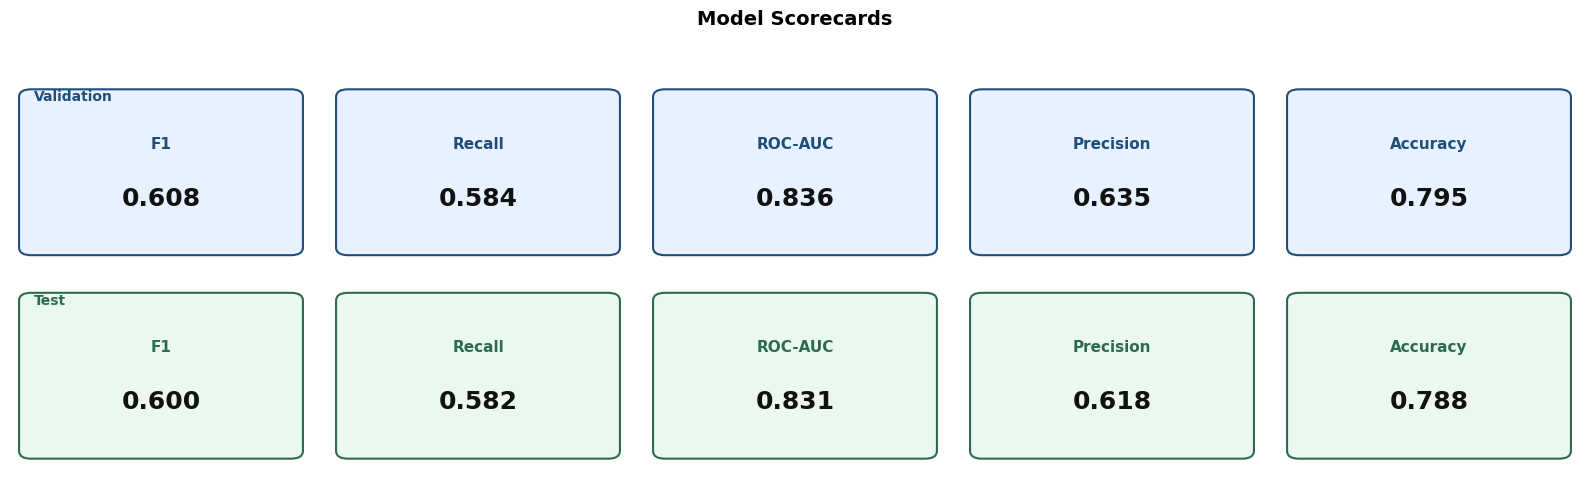

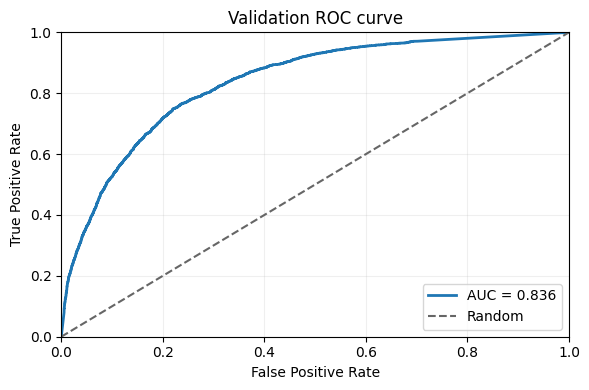

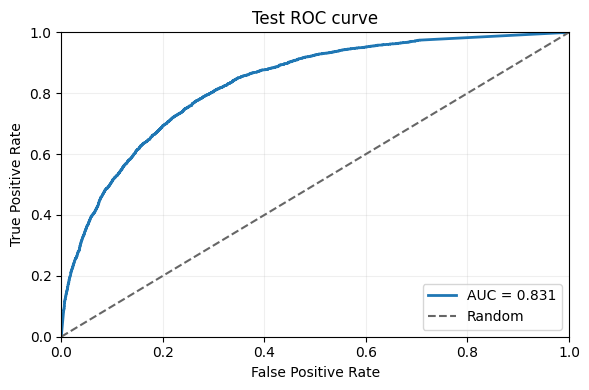

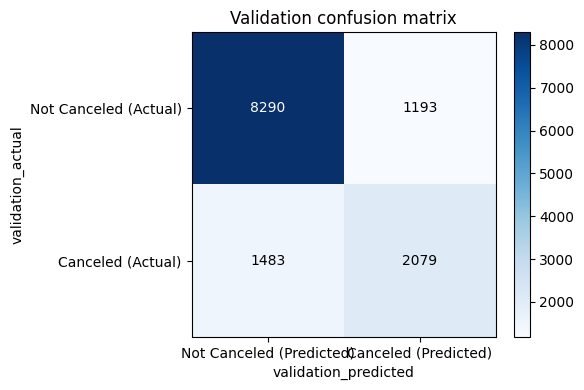

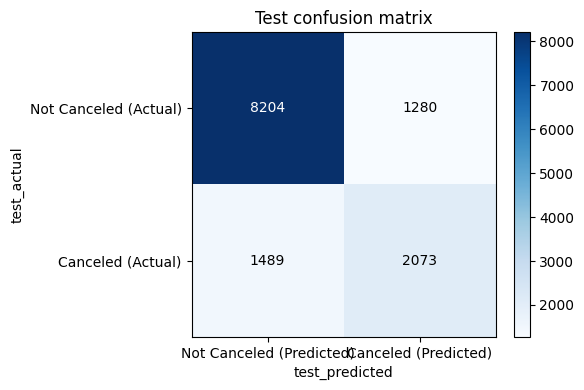

,split,accuracy,precision,recall,f1,roc_auc
0,validation,0.7949,0.6354,0.5837,0.6084,0.8361
1,test,0.7878,0.6183,0.5820,0.5996,0.8305


In [5]:
val_results = evaluate_classifier(best_knn, X_val, y_val, 'validation')
test_results = evaluate_classifier(best_knn, X_test, y_test, 'test')
plot_metric_scorecards(val_results, test_results)
plot_roc_curve(best_knn, X_val, y_val, 'validation')
plot_roc_curve(best_knn, X_test, y_test, 'test')
val_cm = get_confusion_matrix_df(best_knn, X_val, y_val, 'validation', plot=True)
test_cm = get_confusion_matrix_df(best_knn, X_test, y_test, 'test', plot=True)

results_df = pd.DataFrame([val_results, test_results])
display(results_df.round(4))